In [1]:
import matplotlib.pyplot as plt
import numpy as np
import graph_style as gs
from scipy.optimize import curve_fit
from matplotlib.ticker import FormatStrFormatter
import fig_helper as fh




In [3]:

def make_data(times, sideband_idx):
    """Stack together probe durations with sideband index for ..."""
    return np.vstack((times, np.full(len(times), sideband_idx)))


def thermal_sideband_flop(data, eta_omega, n_bar, a, c, n_max=100):
    """Calculate the population for a square probe pulse of the given duration on a
    (plus/minus) first motional sideband.

    :param data: An array of shape (2, n), where the first axis enumerates a tuple of
        pulse duration and sign of the sideband to consider (-1 for RSB, 1 for BSB),
        and the calculation is broadcast across the second axis.
    :param eta_omega: The effective sideband Rabi frequency.
    :param n_bar: The mean occupation number of the thermal state.
    :param a: Fudge factor for the amplitude of the oscillations.
    :param c: Fudge factor adding a constant vertical offset to the oscillations.
    :param n_max: The number of Fock states to consider in the calculation. Should be
        large enough (i.e. much larger than n_bar) so there is negligible population in
        the trucated states.

    :return: An array of shape (n,), giving the resulting populations (starting at 1).
    """
    t, sideband_sign = data

    ns = np.arange(n_max)
    omega_eff = eta_omega * (ns + (1 + sideband_sign[:, np.newaxis]) / 2) ** 0.5
    pop = 0.5 * (1 - np.cos(omega_eff * t[:, np.newaxis]))

    weights = (n_bar / (1 + n_bar)) ** ns / (1 + n_bar)
    weights /= np.sum(weights)

    return a * (1 - np.sum(pop * weights, axis=1)) + c


def thermal_dist(n_bar, n_max=100):
    ns = np.arange(n_max)
    weights = (n_bar / (1 + n_bar)) ** ns / (1 + n_bar)
    weights /= np.sum(weights)
    return weights


gs.set_graph_style(1.0)

date = "2025-04-29"
rid = 22922

data_dict = fh.load_data(rid, date)
# for x in data_dict["datasets"].keys():
#   print(x)


In [4]:

duration = np.array(data_dict["datasets"][f"ndscan.rid_{rid}.point._axis_0"]) * 1e6
y_b = np.array(
    data_dict["datasets"][
        f"ndscan.rid_{rid}.point._channel_readout_pi_rsb_pi_measurement_1_p"
    ]
)
y_b_err = np.array(
    data_dict["datasets"][
        f"ndscan.rid_{rid}.point._channel_readout_pi_rsb_pi_measurement_1_p_err"
    ]
)
y_r = np.array(
    data_dict["datasets"][
        f"ndscan.rid_{rid}.point._channel_readout_rsb_measurement_1_p"
    ]
)
y_r_err = np.array(
    data_dict["datasets"][
        f"ndscan.rid_{rid}.point._channel_readout_rsb_measurement_1_p_err"
    ]
)
eta_omega = np.array(data_dict["datasets"][f"ndscan.rid_{rid}.point._eta_omega"])
eta_omega_err = np.array(
    data_dict["datasets"][f"ndscan.rid_{rid}.point._eta_omega_err"]
)
nbar = np.array(data_dict["datasets"][f"ndscan.rid_{rid}.point._nbar"])
nbar_err = np.array(data_dict["datasets"][f"ndscan.rid_{rid}.point._nbar_err"])

sort_index = np.argsort(duration)
duration = duration[sort_index]
y_b = y_b[sort_index]
y_b_err = y_b_err[sort_index]
y_r = y_r[sort_index]
y_r_err = y_r_err[sort_index]


x = np.hstack((make_data(duration, 1), make_data(duration, -1)))
y = np.hstack((y_b, y_r))
y_err = np.hstack((y_b_err, y_r_err))
a0 = 1
c0 = 0
t_pi = 80

p_fit, p_cov = curve_fit(
    thermal_sideband_flop,
    x,
    y,
    p0=[2 * np.pi / t_pi, 0.1, a0, c0],
    sigma=y_err,
    absolute_sigma=True,
)

n_bar = p_fit[1]

fock_state = thermal_dist(n_bar, n_max=10)

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\d'
<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\d'
<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\d'
C:\Users\webbd\AppData\Local\Temp\ipykernel_37008\2871502226.py:11: SyntaxWarning: invalid escape sequence '\p'
  label="Thermal $\pi$-RSB-$\pi$ fit",
C:\Users\webbd\AppData\Local\Temp\ipykernel_37008\2871502226.py:28: SyntaxWarning: invalid escape sequence '\d'
  ax[0].set_ylabel("$P_\downarrow$ $\pi$-RSB-$\pi$")
C:\Users\webbd\AppData\Local\Temp\ipykernel_37008\2871502226.py:55: SyntaxWarning: invalid escape sequence '\m'
  ax[1].set_xlabel("Duration $t$ ($\mu$s)")
C:\Users\webbd\AppData\Local\Temp\ipykernel_37008\2871502226.py:56: SyntaxWarning: invalid escape sequence '\d'
  ax[1].

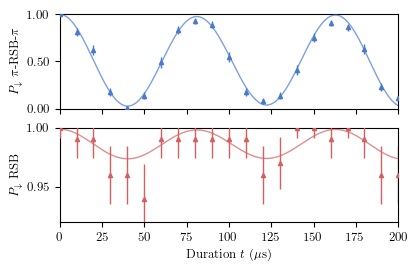

In [10]:

fig_width = gs.get_fig_width() * 3/4
fig_height = 1 * fig_width / gs.get_phi()
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(fig_width, fig_height))
cb = gs.get_color(0)
cr = gs.get_color(2)

linspace = np.linspace(0, np.max(duration), 1000)
ax[0].plot(
    linspace,
    thermal_sideband_flop(make_data(linspace, 1), *p_fit),
    label="Thermal $\pi$-RSB-$\pi$ fit",
    zorder=10,
    color=cb,
    alpha=gs.get_alpha(),
    ls="-"
)

ax[0].errorbar(
    duration,
    y_b,
    yerr=y_b_err,
    fmt="^",
    label="pi_rsb_pi_p",
    color=cb,
    zorder=11,
    elinewidth=1.0,
)
ax[0].set_ylabel("$P_\downarrow$ $\pi$-RSB-$\pi$")
ax[0].set_ylim([0, 1.0])
ax[0].set_xlim([0, np.max(duration)])
ax[1].set_ylim([0.92, 1.0])
ax[1].set_xlim([0, np.max(duration)])


ax[1].plot(
    linspace,
    thermal_sideband_flop(make_data(linspace, -1), *p_fit),
    label="Thermal RSB fit",
    color=cr,
    zorder=10,
    alpha=gs.get_alpha(),
    ls="-"
)

ax[1].errorbar(
    duration,
    y_r,
    yerr=y_r_err,
    fmt="^",
    label="rsb_p",
    zorder=11,
    color=cr,
    elinewidth=1.0,
)
ax[1].set_xlabel("Duration $t$ ($\mu$s)")
ax[1].set_ylabel("$P_\downarrow$ RSB")

ax[0].yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
ax[1].yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
# add label "b" and "c" to the top left corner
for ax_ in ax:
    ax_.grid(None)

f_name = "..\\..\\pdf_figure\\ch4\\sideband_thermometry.pdf"
plt.savefig(f_name, bbox_inches="tight")
